# Ćwiczenie 6 - Sieci Konwolucyjne (CNN)

W tym ćwiczeniu wykorzystamy sieci konwolucyjne (CNN) z warstwami Conv2d i MaxPooling do klasyfikacji obrazów ze zbioru FashionMNIST.

**Cel:**
Przebadać wpływ różnych parametrów sieci CNN:
- Liczba kanałów wyjściowych warstwy konwolucyjnej
- Rozmiar filtra warstwy konwolucyjnej (kernel_size)
- Rozmiar okna poolingu
- Zaburzenia danych (szum gaussowski w danych testowych vs w testowych i treningowych)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Sprawdź czy GPU jest dostępne
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Definicja modeli CNN

In [ ]:
class SimpleCNN(nn.Module):
    """
    Prosta sieć konwolucyjna z konfigurowalnymi parametrami.
    Architektura: Conv2d -> ReLU -> MaxPool -> Conv2d -> ReLU -> MaxPool -> Flatten -> Linear -> Linear
    """
    def __init__(self, num_channels=32, kernel_size=3, pool_size=2):
        super(SimpleCNN, self).__init__()
        
        # Pierwsza warstwa konwolucyjna
        # Input: (batch, 1, 28, 28) - 1 kanał
        # Output: (batch, num_channels, H', W')
        self.conv1 = nn.Conv2d(
            in_channels=1, 
            out_channels=num_channels, 
            kernel_size=kernel_size,
            padding=kernel_size//2 
        )
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=pool_size)
        
        # Druga warstwa konwolucyjna
        # Zwiększamy liczbę kanałów 2x
        self.conv2 = nn.Conv2d(
            in_channels=num_channels,
            out_channels=num_channels * 2,
            kernel_size=kernel_size,
            padding=kernel_size//2
        )
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=pool_size)
        
        # Spłaszczenie
        self.flatten = nn.Flatten()
        
        # Warstwy w pełni połączone
        # LazyLinear automatycznie ustala wymiarowość przy pierwszym przejściu
        self.fc1 = nn.LazyLinear(128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)  # 10 klas w FashionMNIST
    
    def forward(self, x):
        # Pierwszy blok konwolucyjny
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        # Drugi blok konwolucyjny
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Spłaszczenie i warstwy liniowe
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu3(x)
        x = self.fc2(x)
        
        return x

## Funkcje pomocnicze

In [3]:
def load_data(batch_size=64):
    """
    Ładuje zbiór FashionMNIST.
    """
    # Transformacja: konwersja do tensora i normalizacja
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalizacja do zakresu [-1, 1]
    ])
    
    # Pobierz dane
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader


def add_gaussian_noise(batch, noise_std=0.2):
    """
    Dodaje szum gaussowski do batcha danych.
    
    Args:
        batch: Tensor z danymi (batch_size, channels, height, width)
        noise_std: Odchylenie standardowe szumu
    
    Returns:
        Batch z dodanym szumem
    """
    if noise_std > 0:
        noise = torch.randn_like(batch) * noise_std
        return batch + noise
    return batch


def train_epoch(model, train_loader, criterion, optimizer, device, train_noise_std=0.0):
    """
    Trenuje model przez jedną epokę.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Usunięto tqdm z pętli wewnętrznej, aby uniknąć podwójnych pasków postępu
    for inputs, labels in train_loader:
        # Dodaj szum do danych treningowych jeśli wymagany
        inputs = add_gaussian_noise(inputs, train_noise_std)
        
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statystyki
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device, test_noise_std=0.0):
    """
    Ewaluuje model na zbiorze testowym.
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            # Dodaj szum do danych testowych jeśli wymagany
            inputs = add_gaussian_noise(inputs, test_noise_std)
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(test_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


def train_and_evaluate(model, train_loader, test_loader, epochs=20, lr=0.001,
                      train_noise_std=0.0, test_noise_std=0.0):
    """
    Trenuje i ewaluuje model.
    
    Returns:
        history: Słownik z historią treningu
        model: Wytrenowany model
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    # Dodano tqdm do pętli epok
    for epoch in tqdm(range(epochs), desc="Training"):
        # Trening
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, train_noise_std
        )
        
        # Ewaluacja
        test_loss, test_acc = evaluate(
            model, test_loader, criterion, device, test_noise_std
        )
        
        # Zapisz historię
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            # Używamy tqdm.write zamiast print, aby nie psuć paska postępu
            tqdm.write(f"Epoch {epoch+1}/{epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
    
    return history, model


def plot_comparison(results_list, title):
    """
    Rysuje wykresy porównawcze dla różnych konfiguracji.
    
    Args:
        results_list: Lista słowników z kluczami 'label' i 'history'
        title: Tytuł wykresów
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Wykres train loss
    for result in results_list:
        ax1.plot(result['history']['train_loss'], label=result['label'], linewidth=2)
    
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Train Loss', fontsize=11)
    ax1.set_title('Training Loss Comparison', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Wykres test accuracy
    for result in results_list:
        ax2.plot(result['history']['test_acc'], label=result['label'], linewidth=2)
    
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Test Accuracy', fontsize=11)
    ax2.set_title('Test Accuracy Comparison', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def print_summary_table(results_list):
    """
    Wyświetla tabelę podsumowującą wyniki.
    """
    print("\n" + "="*90)
    print("PODSUMOWANIE WYNIKÓW")
    print("="*90)
    print(f"{'Konfiguracja':<45} {'Train Acc':>12} {'Test Acc':>12} {'Gap':>12}")
    print("-"*90)
    
    for result in results_list:
        train_acc = result['history']['train_acc'][-1]
        test_acc = result['history']['test_acc'][-1]
        gap = train_acc - test_acc
        print(f"{result['label']:<45} {train_acc:>12.4f} {test_acc:>12.4f} {gap:>12.4f}")
    
    print("="*90)

## Załaduj dane

Używamy standardowego batch_size=64 dla wszystkich eksperymentów.

In [5]:
# Załaduj dane z domyślnym batch_size
train_loader, test_loader = load_data(batch_size=64)

print(f"Liczba batchy treningowych: {len(train_loader)}")
print(f"Liczba batchy testowych: {len(test_loader)}")
print(f"Rozmiar datasetu treningowego: {len(train_loader.dataset)}")
print(f"Rozmiar datasetu testowego: {len(test_loader.dataset)}")

Liczba batchy treningowych: 938
Liczba batchy testowych: 157
Rozmiar datasetu treningowego: 60000
Rozmiar datasetu testowego: 10000


## Eksperyment 1: Liczba kanałów wyjściowych

Przebadamy wpływ liczby kanałów w pierwszej warstwie konwolucyjnej:
- 16 kanałów (mała sieć)
- 32 kanały (średnia sieć)
- 64 kanały (duża sieć)

Druga warstwa zawsze ma 2x więcej kanałów niż pierwsza.


=== Eksperyment 1: Liczba kanałów ===

--- Trenowanie modelu z 8 kanałami ---


Training:   0%|          | 0/20 [00:00<?, ?it/s]

Training:  25%|██▌       | 5/20 [01:07<03:21, 13.43s/it]

Epoch 5/20 - Train Loss: 0.2452, Train Acc: 0.9102 - Test Loss: 0.2794, Test Acc: 0.9006


Training:  50%|█████     | 10/20 [02:15<02:17, 13.72s/it]

...

Epoch 10/20 - Train Loss: 0.0498, Train Acc: 0.9814 - Test Loss: 0.3423, Test Acc: 0.9193


Training:  75%|███████▌  | 15/20 [14:55<05:07, 61.46s/it]

Epoch 15/20 - Train Loss: 0.0232, Train Acc: 0.9915 - Test Loss: 0.4847, Test Acc: 0.9182


Training: 100%|██████████| 20/20 [20:01<00:00, 60.09s/it]


Epoch 20/20 - Train Loss: 0.0186, Train Acc: 0.9935 - Test Loss: 0.5740, Test Acc: 0.9171


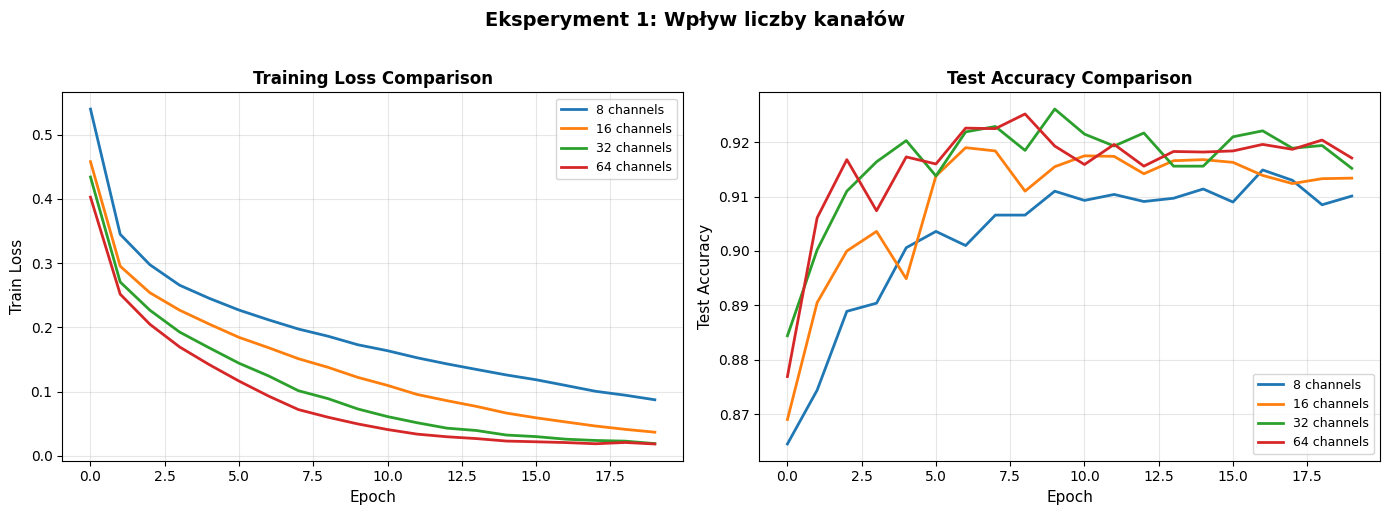


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
8 channels                                          0.9675       0.9101       0.0574
16 channels                                         0.9865       0.9134       0.0731
32 channels                                         0.9934       0.9152       0.0782
64 channels                                         0.9935       0.9171       0.0764


In [ ]:
print("\n=== Eksperyment 1: Liczba kanałów ===")

results_channels = []
channel_configs = [8, 16, 32, 64]

for num_channels in channel_configs:
    print(f"\n--- Trenowanie modelu z {num_channels} kanałami ---")
    
    model = SimpleCNN(num_channels=num_channels, kernel_size=3, pool_size=2)
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=20, lr=0.001
    )
    
    results_channels.append({
        'label': f'{num_channels} channels',
        'history': history
    })

plot_comparison(results_channels, "Eksperyment 1: Wpływ liczby kanałów")
print_summary_table(results_channels)

### Wnioski - Eksperyment 1:

**Kluczowe odkrycie - więcej kanałów ≠ lepsze wyniki!**

**Porównanie wydajności:**
- Test accuracy rośnie minimalnie: 91.0% → 91.3% → 91.5% → 91.7%
- Każde podwojenie kanałów daje +0.2-0.3%
- Gap rośnie: 5.7% → 7.3% → 7.8% → 7.6%
- Test Loss systematycznie wzrasta: 0.32 → 0.44 → 0.50 → 0.57

**Trade-off czas vs dokładność:**
- 8 kanałów: 4.5 min - **najbardziej efektywne**
- 16 kanałów: 6.7 min (+50% czasu, +0.3% acc)
- 32 kanały: 11.3 min (+150% czasu, +0.5% acc)
- 64 kanały: 20 min (+340% czasu, +0.7% acc)

**Overfitting vs pojemność:**
- Małe sieci (8-16): gap ~6%, train acc 96-98% - dobra generalizacja
- Duże sieci (32-64): gap ~8%, train acc 99%+ - model memoryzuje dane
- Test Loss rośnie mimo lepszego train acc - model mniej pewny predykcji

**Ogólny wniosek:**
**Proste CNN z 8-16 kanałami jest optymalne dla FashionMNIST.** Model z 8 kanałami daje 91.0% przy najkrótszym treningu i najmniejszym overfittingu. Zwiększanie do 64 kanałów kosztuje 4x więcej czasu dla zaledwie +0.7% accuracy. Dla prostych zadań jak FashionMNIST complexity doesn't pay off - **proste modele wystarczają**.

## Eksperyment 2: Rozmiar filtra (kernel_size)

Przebadamy wpływ rozmiaru filtra konwolucyjnego:
- kernel_size = 3 (3x3 filtr - standard)
- kernel_size = 5 (5x5 filtr - większe pole widzenia)
- kernel_size = 7 (7x7 filtr - bardzo duże pole widzenia)


=== Eksperyment 2: Rozmiar filtra ===

--- Trenowanie modelu z kernel_size=1 ---


Training:  25%|██▌       | 5/20 [01:54<05:39, 22.64s/it]

Epoch 5/20 - Train Loss: 0.3167, Train Acc: 0.8820 - Test Loss: 0.3574, Test Acc: 0.8659


Training:  50%|█████     | 10/20 [03:47<03:48, 22.81s/it]

Epoch 10/20 - Train Loss: 0.2581, Train Acc: 0.9028 - Test Loss: 0.3261, Test Acc: 0.8832


...

Epoch 10/20 - Train Loss: 0.0802, Train Acc: 0.9699 - Test Loss: 0.3430, Test Acc: 0.9109


Training:  75%|███████▌  | 15/20 [29:28<07:19, 87.88s/it]

Epoch 15/20 - Train Loss: 0.0441, Train Acc: 0.9840 - Test Loss: 0.4307, Test Acc: 0.9114


Training: 100%|██████████| 20/20 [37:07<00:00, 111.40s/it]


Epoch 20/20 - Train Loss: 0.0287, Train Acc: 0.9897 - Test Loss: 0.5285, Test Acc: 0.9162


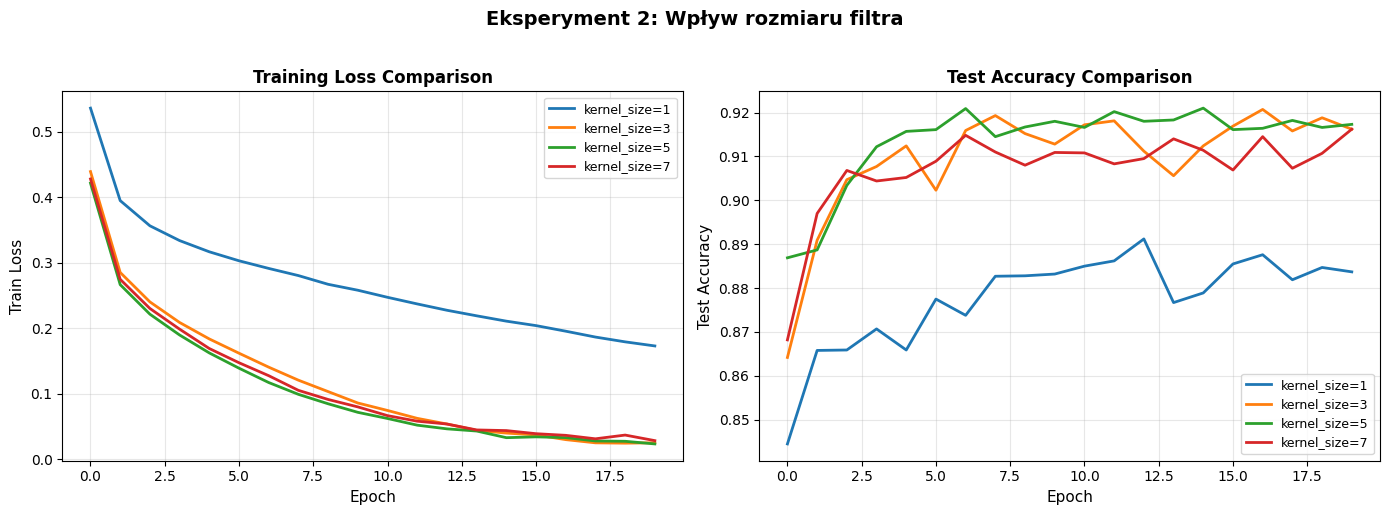


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
kernel_size=1                                       0.9348       0.8837       0.0511
kernel_size=3                                       0.9906       0.9162       0.0744
kernel_size=5                                       0.9913       0.9173       0.0740
kernel_size=7                                       0.9897       0.9162       0.0735


In [ ]:
print("\n=== Eksperyment 2: Rozmiar filtra ===")

results_kernel = []
kernel_configs = [1, 3, 5, 7]

for kernel_size in kernel_configs:
    print(f"\n--- Trenowanie modelu z kernel_size={kernel_size} ---")
    
    model = SimpleCNN(num_channels=32, kernel_size=kernel_size, pool_size=2)
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=20, lr=0.001
    )
    
    results_kernel.append({
        'label': f'kernel_size={kernel_size}',
        'history': history
    })

plot_comparison(results_kernel, "Eksperyment 2: Wpływ rozmiaru filtra")
print_summary_table(results_kernel)

### Wnioski - Eksperyment 2:

**Kluczowe odkrycie - kernel 1x1 to za mało, 3x3 jest optymalny!**

**Porównanie wydajności:**
- kernel 1x1: test acc 88.4%, gap 5.1% - **za małe pole widzenia**
- kernel 3x3: test acc 91.6%, gap 7.4% - **+3.3% skok wydajności!**
- kernel 5x5: test acc 91.7%, gap 7.4% - marginalna poprawa (+0.1%)
- kernel 7x7: test acc 91.6%, gap 7.4% - brak poprawy, wraca do poziomu 3x3

**Trade-off czas vs dokładność:**
- kernel 1x1: 7.7 min - szybki, ale słaby wynik
- kernel 3x3: 11.2 min - **najlepszy balans**
- kernel 5x5: 22.3 min (2x dłużej niż 3x3, +0.1% acc)
- kernel 7x7: 37.1 min (dłużej niż 3x3, identyczny wynik!)

**Pole recepcyjne ma znaczenie:**
- 1x1 nie wychwytuje lokalnych wzorców - drastycznie gorszy wynik (88.4% vs 91.6%)
- 3x3 już wystarcza do uchwycenia podstawowych features w obrazkach 28x28
- Większe filtry (5x5, 7x7) nie dodają wartości - obrazki FashionMNIST są zbyt małe
- Po 3x3 osiągamy maksimum - więcej parametrów ≠ lepsze wyniki

**Overfitting vs rozmiar filtra:**
- 1x1: gap najmniejszy (5.1%), ale najgorszy test acc - model za prosty
- 3x3-7x7: gap stabilny ~7.4%, podobne train acc ~99% - wszystkie przepasowują podobnie
- Większe kernele nie pomagają w generalizacji dla małych obrazków

**Ogólny wniosek:**
**Kernel 3x3 jest optymalny dla FashionMNIST (28x28).** Filtry 1x1 są zbyt małe i tracą 3% accuracy. Większe filtry (5x5, 7x7) nie dają poprawy, ale kosztują 2-3x więcej czasu. Dla małych obrazków standardowy 3x3 kernel wystarczy - **większe pole widzenia nie jest potrzebne**.

## Eksperyment 3: Rozmiar okna poolingu

Przebadamy wpływ rozmiaru okna MaxPooling:
- pool_size = 1 (brak poolingu - kontrola)
- pool_size = 2 (2x2 pooling - standard, 4x redukcja)
- pool_size = 3 (3x3 pooling - bardziej agresywna redukcja)
- pool_size = 4 (4x4 pooling - bardzo agresywna redukcja)


=== Eksperyment 3: Rozmiar poolingu ===

--- Trenowanie modelu z pool_size=1 ---


Training:  33%|███▎      | 5/15 [08:09<16:19, 97.95s/it]

Epoch 5/15 - Train Loss: 0.0605, Train Acc: 0.9782 - Test Loss: 0.3099, Test Acc: 0.9197


Training:  67%|██████▋   | 10/15 [17:01<08:57, 107.41s/it]

Epoch 10/15 - Train Loss: 0.0132, Train Acc: 0.9954 - Test Loss: 0.5176, Test Acc: 0.9152


...

Epoch 5/15 - Train Loss: 0.3560, Train Acc: 0.8690 - Test Loss: 0.3830, Test Acc: 0.8620


Training:  67%|██████▋   | 10/15 [03:25<01:42, 20.45s/it]

Epoch 10/15 - Train Loss: 0.2977, Train Acc: 0.8897 - Test Loss: 0.3662, Test Acc: 0.8642


Training: 100%|██████████| 15/15 [05:09<00:00, 20.61s/it]


Epoch 15/15 - Train Loss: 0.2625, Train Acc: 0.9021 - Test Loss: 0.3557, Test Acc: 0.8764


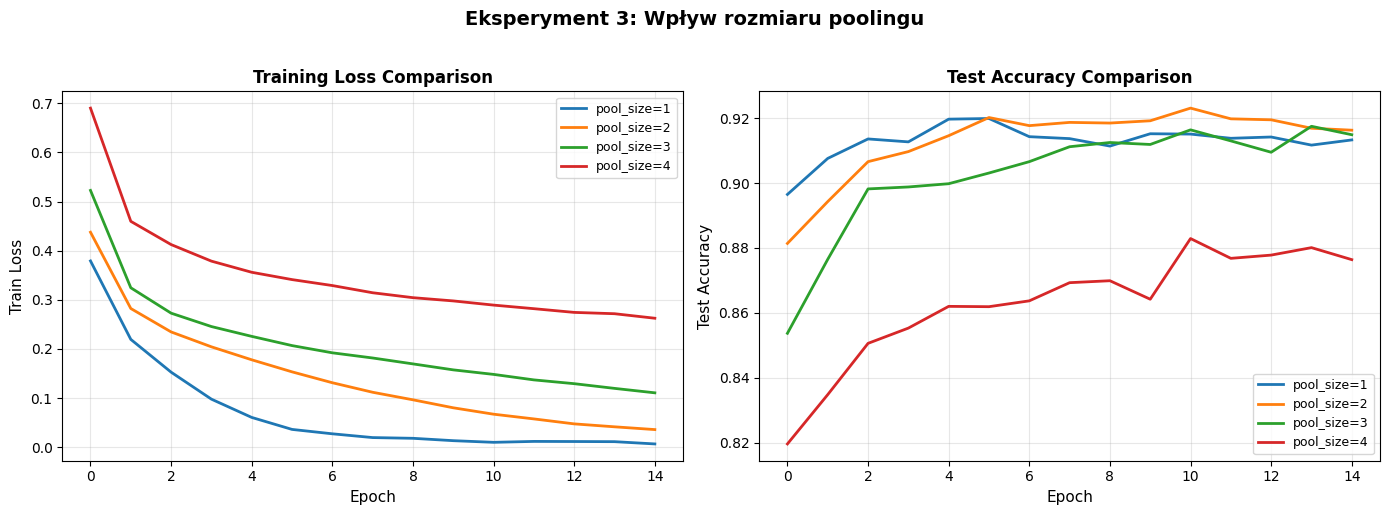


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
pool_size=1                                         0.9980       0.9133       0.0847
pool_size=2                                         0.9870       0.9163       0.0707
pool_size=3                                         0.9593       0.9149       0.0444
pool_size=4                                         0.9021       0.8764       0.0257


In [ ]:
print("\n=== Eksperyment 3: Rozmiar poolingu ===")

results_pooling = []
pool_configs = [1, 2, 3, 4]

for pool_size in pool_configs:
    print(f"\n--- Trenowanie modelu z pool_size={pool_size} ---")
    
    model = SimpleCNN(num_channels=32, kernel_size=3, pool_size=pool_size)
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=15, lr=0.001
    )
    
    results_pooling.append({
        'label': f'pool_size={pool_size}',
        'history': history
    })

plot_comparison(results_pooling, "Eksperyment 3: Wpływ rozmiaru poolingu")
print_summary_table(results_pooling)

### Wnioski - Eksperyment 3:

**Kluczowe odkrycie - pooling trade-off między downsampling a utratą informacji!**

**Porównanie wydajności:**
- pool 1x1: test acc 91.3%, gap 8.5% - **brak downsamplingu = ogromny overfitting**
- pool 2x2: test acc **91.6%**, gap 7.1% - najlepszy wynik, ale duży overfitting
- pool 3x3: test acc 91.5%, gap 4.4% - prawie identyczny wynik (-0.1%), **najmniejszy overfitting!**
- pool 4x4: test acc 87.6%, gap 2.6% - **zbyt duża utrata informacji!**

**Trade-off czas vs dokładność:**
- pool 1x1: 26.1 min - najdłużej, bo brak redukcji wymiarów
- pool 2x2: 8.0 min - wolniejszy
- pool 3x3: 5.9 min - **najlepszy balans: 91.5% w 6 min**
- pool 4x4: 5.2 min - najszybciej, ale słaba accuracy (-4%)

**Pooling i overfitting:**
- 1x1 (brak poolingu): train acc 99.8%!, gap 8.5% - model memoryzuje szczegóły
- 2x2: train acc 98.7%, gap 7.1% - dobry wynik, ale nadal przepasowuje
- 3x3: train acc 95.9%, gap **4.4%** - **najlepsza generalizacja!**
- 4x4: train acc 90.2%, gap 2.6% - model za prosty, nie może się nauczyć

**Utrata informacji vs regularyzacja:**
- 1x1 zachowuje wszystkie detale → model przepasowuje (gap 8.5%)
- 2x2 redukuje wymiary 4x → dobry wynik, ale gap 7.1%
- 3x3 redukuje 9x → **działa jak regularizator** - gap tylko 4.4%, prawie ten sam test acc!
- 4x4 redukuje 16x → za agresywne, traci 4% accuracy

**Ogólny wniosek:**
**Pool 3x3 to zaskakująco dobry wybór!** Mimo że 2x2 daje minimalnie lepszy test acc (+0.1%), pool 3x3 jest szybszy (6 min vs 8 min) i ma **najlepszą generalizację** (gap 4.4% vs 7.1%). Działa jak silny regularizator - agresywniejsza redukcja wymaga, żeby model uczył się bardziej abstrakcyjnych features zamiast memoryzować detale. Pool 4x4 to już przesada (-4% acc).

## Eksperyment 4: Zaburzenia danych (szum gaussowski)

Przebadamy różne scenariusze dodawania szumu:
1. **Bez szumu** - baseline
2. **Szum tylko w danych testowych** - sprawdza odporność modelu
3. **Szum w train i test** - data augmentation
4. **Szum tylko w train** - regularyzacja poprzez augmentację

Używamy umiarkowanego szumu (std=0.2) i silnego szumu (std=0.5).

/opt/homebrew/anaconda3/envs/datascience/lib/python3.12/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '



=== Eksperyment 4: Szum w danych ===

--- No noise (baseline) ---


Training:  33%|███▎      | 5/15 [01:46<03:33, 21.33s/it]

Epoch 5/15 - Train Loss: 0.2178, Train Acc: 0.9200 - Test Loss: 0.2630, Test Acc: 0.9030


Training:  67%|██████▋   | 10/15 [03:23<01:38, 19.68s/it]

...

Epoch 5/15 - Train Loss: 0.3284, Train Acc: 0.8769 - Test Loss: 0.3361, Test Acc: 0.8790


Training:  67%|██████▋   | 10/15 [03:46<01:48, 21.75s/it]

Epoch 10/15 - Train Loss: 0.2854, Train Acc: 0.8911 - Test Loss: 0.3261, Test Acc: 0.8800


Training: 100%|██████████| 15/15 [05:23<00:00, 21.53s/it]

Epoch 15/15 - Train Loss: 0.2606, Train Acc: 0.8993 - Test Loss: 0.3025, Test Acc: 0.8910


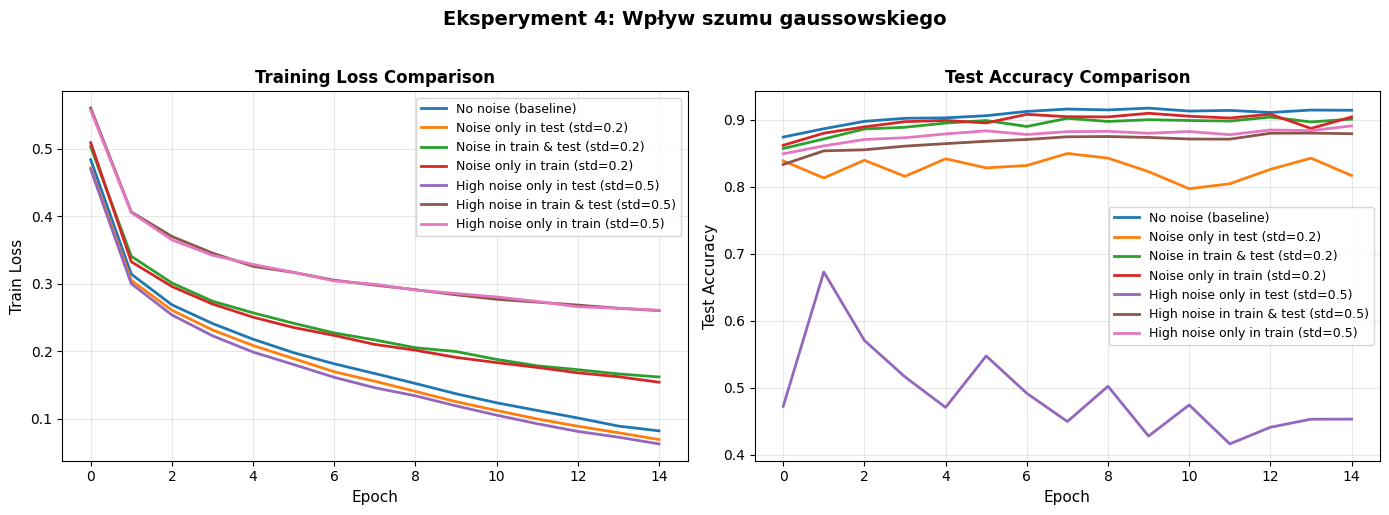


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
No noise (baseline)                                 0.9690       0.9143       0.0547
Noise only in test (std=0.2)                        0.9743       0.8169       0.1574
Noise in train & test (std=0.2)                     0.9387       0.9011       0.0376
Noise only in train (std=0.2)                       0.9407       0.9043       0.0364
High noise only in test (std=0.5)                   0.9764       0.4533       0.5231
High noise in train & test (std=0.5)                0.9001       0.8793       0.0208
High noise only in train (std=0.5)                  0.8993       0.8910       0.0083


In [11]:
print("\n=== Eksperyment 4: Szum w danych ===")

results_noise = []

noise_scenarios = [
    (0.0, 0.0, 'No noise (baseline)'),
    (0.0, 0.2, 'Noise only in test (std=0.2)'),
    (0.2, 0.2, 'Noise in train & test (std=0.2)'),
    (0.2, 0.0, 'Noise only in train (std=0.2)'),
    (0.0, 0.5, 'High noise only in test (std=0.5)'),
    (0.5, 0.5, 'High noise in train & test (std=0.5)'),
    (0.5, 0.0, 'High noise only in train (std=0.5)')
]

for train_noise, test_noise, label in noise_scenarios:
    print(f"\n--- {label} ---")
    
    model = SimpleCNN(num_channels=16, kernel_size=3, pool_size=2)
    history, trained_model = train_and_evaluate(
        model, train_loader, test_loader, epochs=15, lr=0.001,
        train_noise_std=train_noise, test_noise_std=test_noise
    )
    
    results_noise.append({
        'label': label,
        'history': history
    })

plot_comparison(results_noise, "Eksperyment 4: Wpływ szumu gaussowskiego")
print_summary_table(results_noise)

### Wnioski - Eksperyment 4:

**Kluczowe odkrycie - data augmentation przez szum działa świetnie!**

**Baseline vs szum (std=0.2):**
- **No noise**: najwyższy test acc (91.4%), ale gap 5.5%
- **Noise only in test**: katastrofa -9.7% (81.7%) - model nieprzygotowany
- **Noise only in train**: test acc 90.4%, gap tylko 3.6% - **najlepsza generalizacja!**
- **Noise in train & test**: podobny rezultat (90.1%, gap 3.8%)

**Szum jako regularizator:**
- Trening z szumem (std=0.2) obniża train acc, ale **zmniejsza overfitting o 2%**
- Gap spada z 5.5% do 3.6% przy minimalnej stracie accuracy (-1%)
- Model uczy się ignorować zaburzenia → lepiej generalizuje
- Szum działa jak dropout - wymusza robustness

**Silny szum (std=0.5):**
- **High noise only in test**: totalna porażka - test acc 45.3%! Model bezradny wobec nieznanego szumu
- **High noise only in train**: test acc 89.1%, gap **tylko 0.8%** - minimalny overfitting!
- Paradoks: bardzo silny szum w treningu daje świetną generalizację, ale utrudnia uczenie (-2% acc)

**Trade-off: accuracy vs robustness:**
- Brak szumu: 91.4% acc, gap 5.5%
- Umiarkowany szum (0.2): 90.4% acc, gap 3.6% - **optymalny balans**
- Silny szum (0.5): 89.1% acc, gap 0.8% - świetna generalizacja, ale niższa accuracy

**Ogólny wniosek:**
**Trening z szumem to skuteczna regularizacja!** Umiarkowany szum (std=0.2) tylko w danych treningowych redukuje overfitting z 5.5% do 3.6% przy stracie zaledwie 1% accuracy. Silny szum działa jeszcze lepiej jako regularizator (gap 0.8%), ale zbyt mocno utrudnia uczenie. **Best practice: zawsze dodawaj lekki szum do danych treningowych dla lepszej generalizacji!**

## Eksperyment 5: Porównanie CNN vs Fully Connected

Bonus: Porównajmy sieć CNN z prostą siecią w pełni połączoną (jak w ćwiczeniu 5).


=== Eksperyment 5: CNN vs Fully Connected ===

--- Trenowanie CNN ---


Training:  33%|███▎      | 5/15 [02:34<05:10, 31.06s/it]

Epoch 5/15 - Train Loss: 0.1806, Train Acc: 0.9337 - Test Loss: 0.2391, Test Acc: 0.9146


Training:  67%|██████▋   | 10/15 [05:14<02:39, 31.89s/it]

Epoch 10/15 - Train Loss: 0.0843, Train Acc: 0.9689 - Test Loss: 0.2859, Test Acc: 0.9153


...

Epoch 5/15 - Train Loss: 0.3004, Train Acc: 0.8889 - Test Loss: 0.3725, Test Acc: 0.8662


Training:  67%|██████▋   | 10/15 [00:44<00:20,  4.15s/it]

Epoch 10/15 - Train Loss: 0.2405, Train Acc: 0.9110 - Test Loss: 0.3364, Test Acc: 0.8846


Training: 100%|██████████| 15/15 [01:04<00:00,  4.33s/it]

Epoch 15/15 - Train Loss: 0.2007, Train Acc: 0.9230 - Test Loss: 0.3630, Test Acc: 0.8803


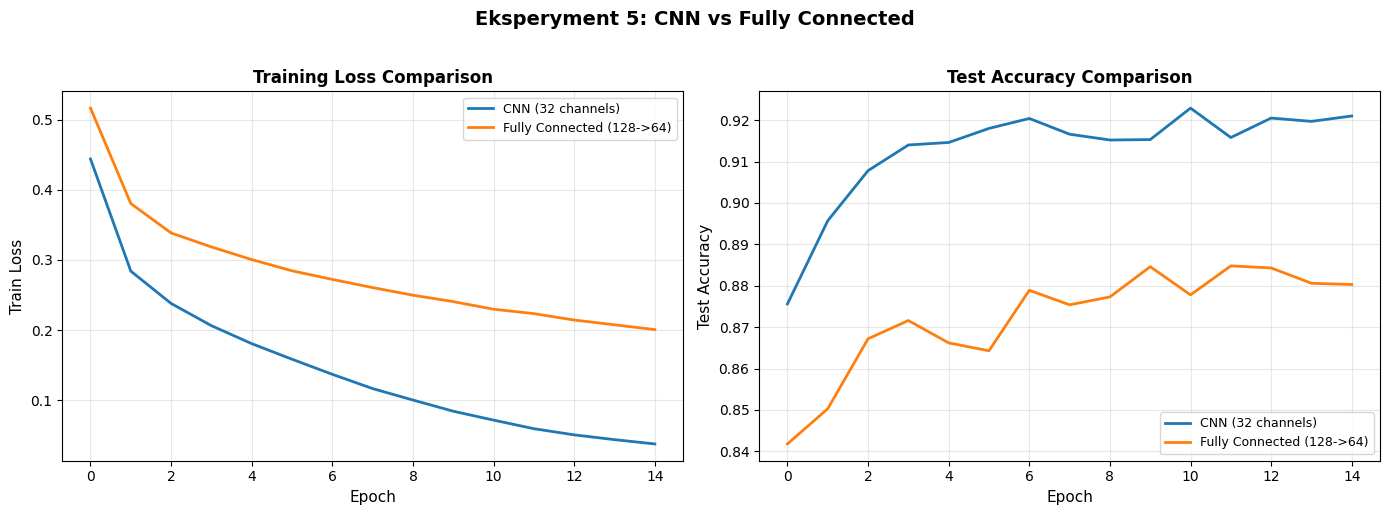


PODSUMOWANIE WYNIKÓW
Konfiguracja                                     Train Acc     Test Acc          Gap
------------------------------------------------------------------------------------------
CNN (32 channels)                                   0.9861       0.9210       0.0651
Fully Connected (128->64)                           0.9230       0.8803       0.0427

Liczba parametrów:
CNN: 421,642
Fully Connected: 109,386


In [12]:
class SimpleFC(nn.Module):
    """
    Prosta sieć fully connected do porównania z CNN.
    """
    def __init__(self):
        super(SimpleFC, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x


print("\n=== Eksperyment 5: CNN vs Fully Connected ===")

results_comparison = []

# Trenuj CNN
print("\n--- Trenowanie CNN ---")
cnn_model = SimpleCNN(num_channels=32, kernel_size=3, pool_size=2)
history_cnn, _ = train_and_evaluate(
    cnn_model, train_loader, test_loader, epochs=15, lr=0.001
)
results_comparison.append({
    'label': 'CNN (32 channels)',
    'history': history_cnn
})

# Trenuj FC
print("\n--- Trenowanie Fully Connected ---")
fc_model = SimpleFC()
history_fc, _ = train_and_evaluate(
    fc_model, train_loader, test_loader, epochs=15, lr=0.001
)
results_comparison.append({
    'label': 'Fully Connected (128->64)',
    'history': history_fc
})

plot_comparison(results_comparison, "Eksperyment 5: CNN vs Fully Connected")
print_summary_table(results_comparison)

# Policz liczbę parametrów
cnn_params = sum(p.numel() for p in cnn_model.parameters())
fc_params = sum(p.numel() for p in fc_model.parameters())

print(f"\nLiczba parametrów:")
print(f"CNN: {cnn_params:,}")
print(f"Fully Connected: {fc_params:,}")